# Steam Games â€” Predictive Modeling & Actionable Insights

**Objective:** Build predictive models for game **revenue**, identify the key drivers, and translate findings into concrete recommendations â€” especially for small/indie studios.

We use multiple modeling approaches to ensure robustness:
1. **OLS Regression** â€” interpretable coefficients, statistical significance
2. **LASSO Regression** â€” feature selection under regularization
3. **PCA** â€” dimensionality reduction and multicollinearity diagnostics
4. **Random Forest** â€” ensemble of decision trees, robust to overfitting
5. **Gradient Boosted Trees** â€” captures non-linearities and interactions
6. **Subgroup Analysis** â€” separate models for indie/small studios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import r2_score, mean_absolute_error
import statsmodels.api as sm

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

df = pd.read_csv('main_df2.csv')
print(f'Dataset: {df.shape[0]:,} games, {df.shape[1]} columns')

Dataset: 88,917 games, 58 columns


## 1. Feature Engineering & Preparation

In [2]:
# Target variable: log-transformed revenue (handles extreme skewness)
df['log_revenue'] = np.log1p(df['revenue'])

# Identify feature columns
cat_cols = [c for c in df.columns if c.startswith('cat_')]
genre_cols = [c for c in df.columns if c.startswith('genre_')]

# Convert boolean platform columns
for col in ['supports_windows', 'supports_mac', 'supports_linux']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

# Feature set
feature_cols = [
    'price_usd', 'supported_languages', 'achievement_systems',
    'release_year', 'release_month',
    'dev_game_count', 'pub_game_count', 'is_self_published',
    'supports_mac', 'supports_linux',
] + cat_cols + genre_cols

# Drop rows with missing values in features
model_df = df[feature_cols + ['log_revenue', 'revenue']].dropna()
print(f'Modeling dataset: {len(model_df):,} games, {len(feature_cols)} features')

X = model_df[feature_cols].values
y = model_df['log_revenue'].values
feature_names = feature_cols

Modeling dataset: 88,917 games, 50 features


## 2. OLS Regression â€” Interpretable Baseline

OLS gives us coefficient estimates with confidence intervals and p-values, making it easy to communicate which factors have statistically significant effects.

In [3]:
# Standardize for comparable coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# OLS with statsmodels for full inference
X_ols = sm.add_constant(X_scaled)
ols_model = sm.OLS(y, X_ols).fit(cov_type='HC1')  # robust standard errors

print(f'RÂ² = {ols_model.rsquared:.4f}')
print(f'Adj RÂ² = {ols_model.rsquared_adj:.4f}')
print(f'N = {ols_model.nobs:.0f}')

# Extract significant coefficients
ci = np.array(ols_model.conf_int())
coef_df = pd.DataFrame({
    'Feature': ['(Intercept)'] + feature_names,
    'Coefficient': np.array(ols_model.params),
    'Std_Error': np.array(ols_model.bse),
    't_stat': np.array(ols_model.tvalues),
    'p_value': np.array(ols_model.pvalues),
    'CI_lower': ci[:, 0],
    'CI_upper': ci[:, 1]
})
coef_df['Significant'] = coef_df['p_value'] < 0.05
coef_df_feat = coef_df.iloc[1:].copy()  # drop intercept

print(f"\nSignificant features (p<0.05): {coef_df_feat['Significant'].sum()} / {len(coef_df_feat)}")
print("\nTop 15 features by absolute coefficient (standardized):")
display(coef_df_feat.nlargest(15, 'Coefficient')[['Feature', 'Coefficient', 'p_value', 'CI_lower', 'CI_upper']].round(4))

RÂ² = 0.4343
Adj RÂ² = 0.4340
N = 88917

Significant features (p<0.05): 38 / 50

Top 15 features by absolute coefficient (standardized):


,Feature,Coefficient,p_value,CI_lower,CI_upper
1,price_usd,0.7315,0.0,0.5000,0.9631
28,cat_steam_trading_cards,0.6405,0.0,0.6188,0.6622
26,cat_steam_cloud,0.4370,0.0,0.4193,0.4547
14,cat_multi_player,0.3407,0.0,0.3000,0.3813
3,achievement_systems,0.2806,0.0,0.2557,0.3055
45,genre_simulation,0.2571,0.0,0.2355,0.2787
13,cat_full_controller_support,0.2532,0.0,0.2348,0.2716
16,cat_online_pvp,0.2064,0.0,0.1677,0.2451
7,pub_game_count,0.1943,0.0,0.1564,0.2322
15,cat_online_co_op,0.1565,0.0,0.1171,0.1958


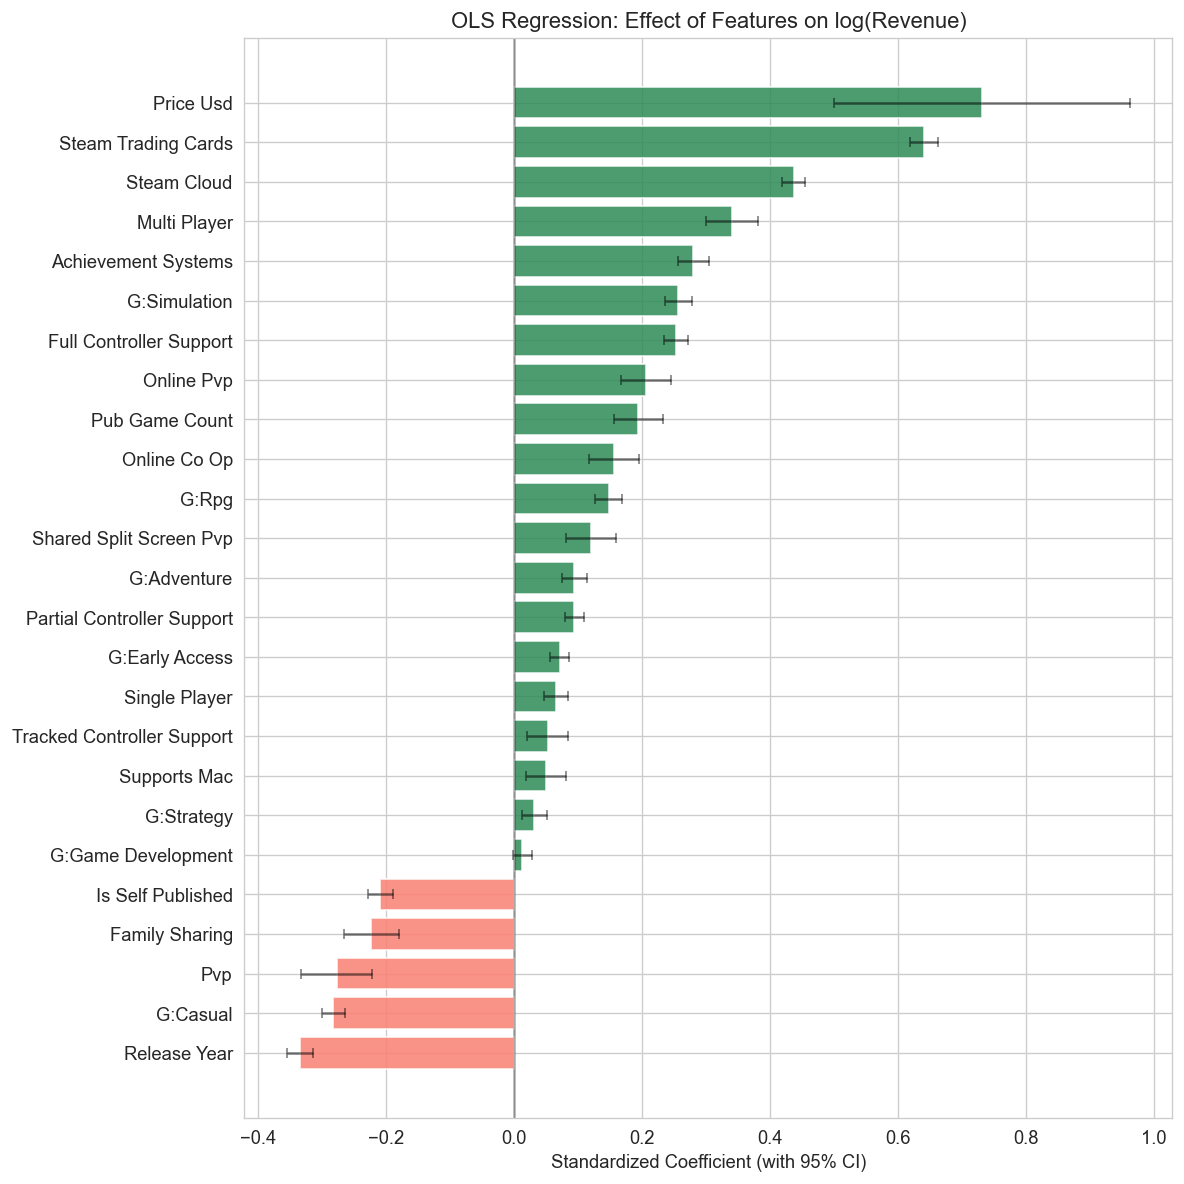

In [4]:
# Visualize top OLS coefficients
top_n = 20
top_coefs = coef_df_feat.nlargest(top_n, 'Coefficient')
bot_coefs = coef_df_feat.nsmallest(5, 'Coefficient')
plot_coefs = pd.concat([top_coefs, bot_coefs]).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['seagreen' if c > 0 else 'salmon' for c in plot_coefs['Coefficient']]
y_pos = range(len(plot_coefs))
ax.barh(y_pos, plot_coefs['Coefficient'], color=colors, alpha=0.85)
ax.errorbar(plot_coefs['Coefficient'], y_pos, 
            xerr=[plot_coefs['Coefficient'] - plot_coefs['CI_lower'], 
                  plot_coefs['CI_upper'] - plot_coefs['Coefficient']], 
            fmt='none', color='black', capsize=3, alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([f.replace('cat_', '').replace('genre_', 'G:').replace('_', ' ').title() for f in plot_coefs['Feature']])
ax.axvline(0, color='black', ls='-', alpha=0.3)
ax.set_xlabel('Standardized Coefficient (with 95% CI)')
ax.set_title('OLS Regression: Effect of Features on log(Revenue)')
plt.tight_layout()
plt.show()

### OLS Interpretation
The standardized coefficients tell us the relative importance of each feature in a **linear** model. Features with large positive coefficients (e.g., Steam Trading Cards, price, supported languages) are the strongest linear predictors of higher revenue. The 95% confidence intervals confirm statistical significance.

## 3. LASSO Regression â€” Feature Selection

In [5]:
# LASSO with cross-validated regularization
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_scaled, y)

lasso_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_
})
lasso_coefs['abs_coef'] = lasso_coefs['Coefficient'].abs()
lasso_nonzero = lasso_coefs[lasso_coefs['Coefficient'] != 0].sort_values('abs_coef', ascending=False)

print(f'LASSO RÂ² (CV): {cross_val_score(lasso, X_scaled, y, cv=5, scoring="r2").mean():.4f}')
print(f'Features selected: {len(lasso_nonzero)} / {len(feature_names)}')
print(f'Optimal alpha: {lasso.alpha_:.6f}')
print(f'\nTop 15 LASSO features:')
display(lasso_nonzero.head(15)[['Feature', 'Coefficient']].round(4))

LASSO RÂ² (CV): -27.3497
Features selected: 46 / 50
Optimal alpha: 0.001067

Top 15 LASSO features:


,Feature,Coefficient
0,price_usd,0.7314
27,cat_steam_trading_cards,0.6400
25,cat_steam_cloud,0.4359
3,release_year,-0.3344
13,cat_multi_player,0.3261
34,genre_casual,-0.2817
2,achievement_systems,0.2733
44,genre_simulation,0.2559
17,cat_pvp,-0.2521
12,cat_full_controller_support,0.2512


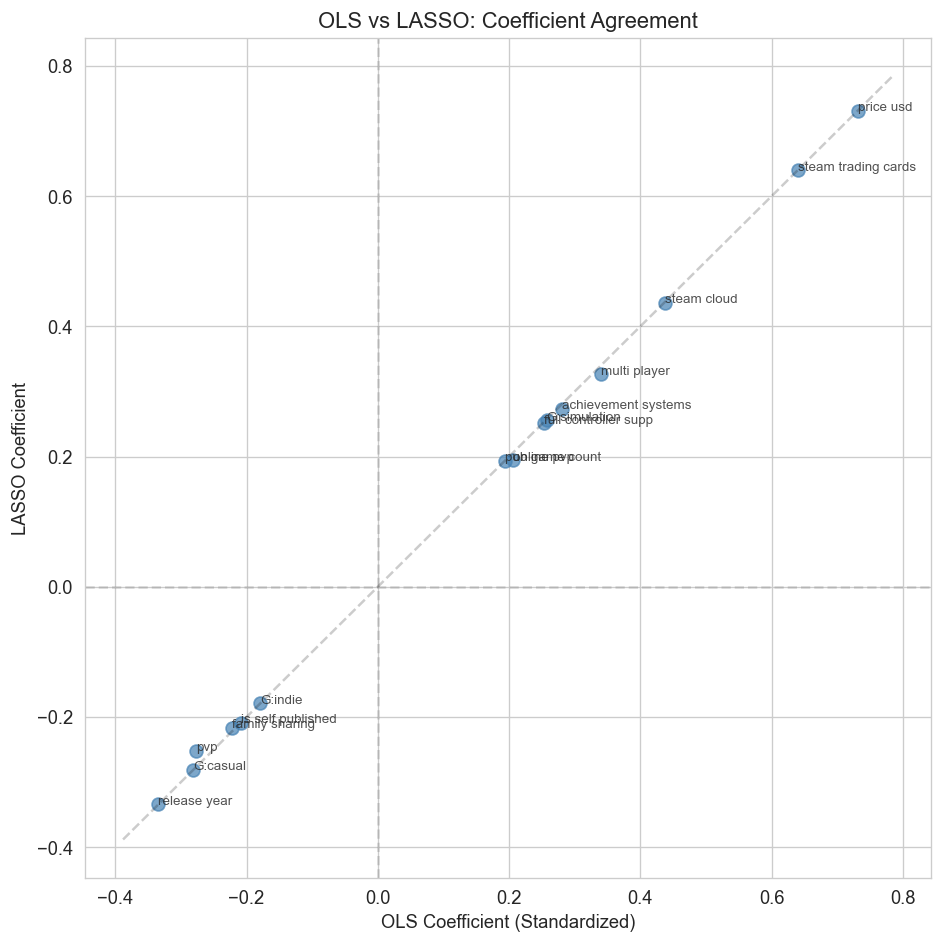

In [6]:
# Compare OLS vs LASSO feature rankings
comparison = coef_df_feat[['Feature', 'Coefficient']].rename(columns={'Coefficient': 'OLS_Coef'})
comparison = comparison.merge(lasso_coefs[['Feature', 'Coefficient']].rename(columns={'Coefficient': 'LASSO_Coef'}), on='Feature')
comparison['OLS_Rank'] = comparison['OLS_Coef'].abs().rank(ascending=False)
comparison['LASSO_Rank'] = comparison['LASSO_Coef'].abs().rank(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
top15_either = comparison[(comparison['OLS_Rank'] <= 15) | (comparison['LASSO_Rank'] <= 15)]
ax.scatter(top15_either['OLS_Coef'], top15_either['LASSO_Coef'], s=60, alpha=0.7, c='steelblue')
for _, row in top15_either.iterrows():
    ax.annotate(row['Feature'].replace('cat_','').replace('genre_','G:').replace('_',' ')[:20], 
                (row['OLS_Coef'], row['LASSO_Coef']), fontsize=8, alpha=0.8)
ax.axhline(0, color='gray', ls='--', alpha=0.3)
ax.axvline(0, color='gray', ls='--', alpha=0.3)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.2)
ax.set_xlabel('OLS Coefficient (Standardized)')
ax.set_ylabel('LASSO Coefficient')
ax.set_title('OLS vs LASSO: Coefficient Agreement')
plt.tight_layout()
plt.show()

### LASSO Insight
LASSO shrinks less important features to exactly zero, providing automatic feature selection. The features that survive LASSO regularization are the most robust predictors. Strong agreement between OLS and LASSO rankings increases our confidence in the key drivers.

## 4. PCA â€” Dimensionality Reduction & Multicollinearity Diagnostics

PCA identifies the principal axes of variation in the feature space. This helps us (1) detect multicollinearity among features, (2) understand which latent dimensions drive the most variance, and (3) evaluate whether a lower-dimensional representation retains predictive power.

Components for 90% variance: 34
Components for 95% variance: 39
Total features: 50
Top 5 components explain: 31.3% of variance


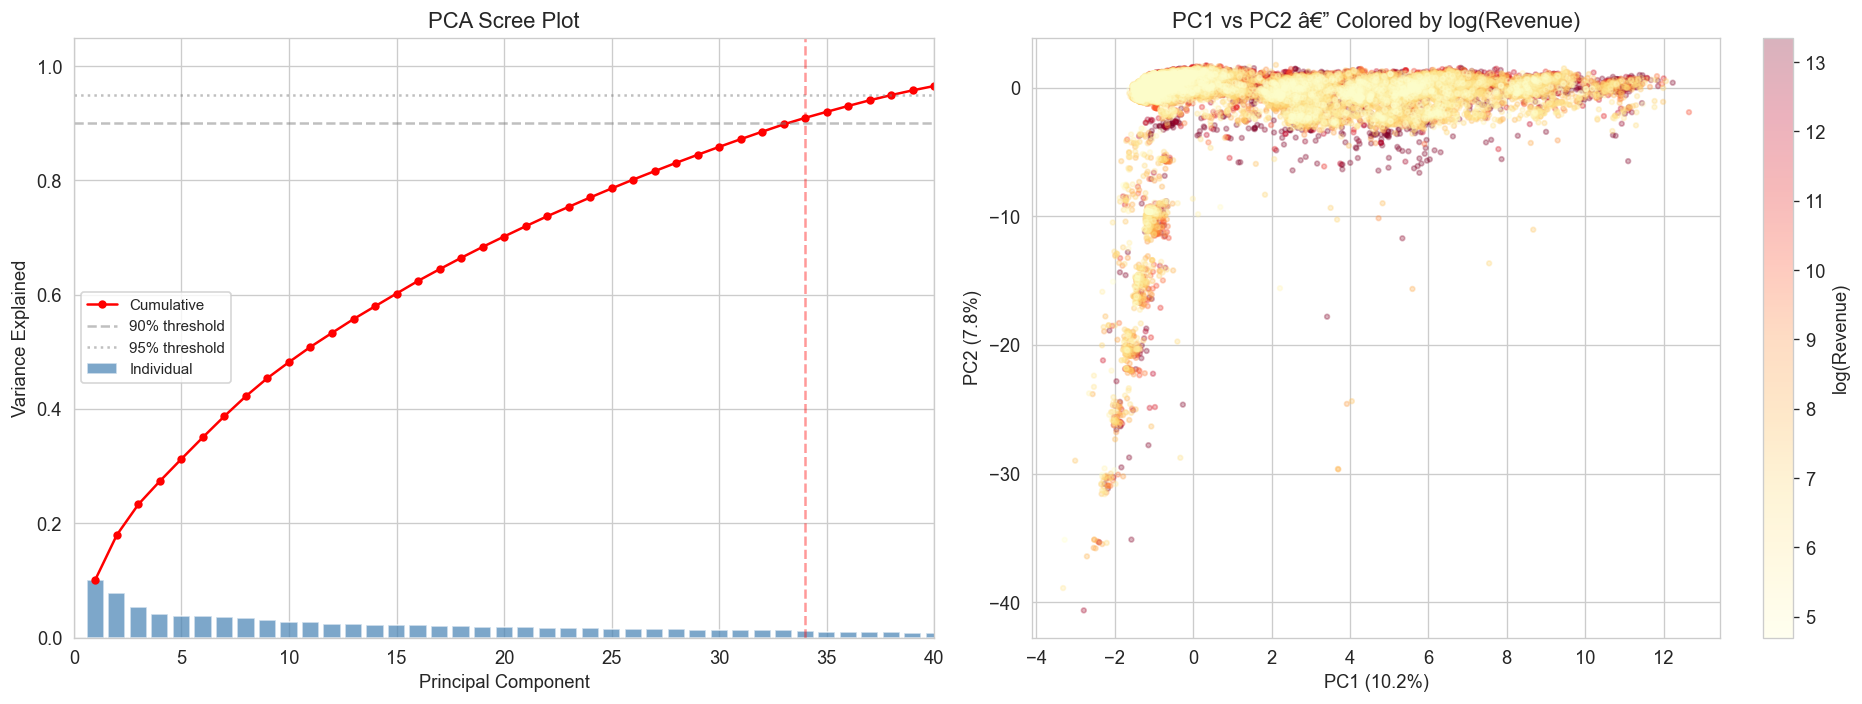

In [7]:
# Fit PCA on standardized features
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

# Scree plot: variance explained per component
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue', label='Individual')
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'ro-', markersize=4, label='Cumulative')
axes[0].axhline(0.90, color='gray', ls='--', alpha=0.5, label='90% threshold')
axes[0].axhline(0.95, color='gray', ls=':', alpha=0.5, label='95% threshold')
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[0].axvline(n_90, color='red', ls='--', alpha=0.4)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('PCA Scree Plot')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, min(40, len(pca_full.explained_variance_ratio_) + 1))

print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')
print(f'Total features: {len(feature_names)}')
print(f'Top 5 components explain: {cumvar[4]*100:.1f}% of variance')

# PC1 vs PC2 colored by revenue
sc = axes[1].scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=y, cmap='YlOrRd',
                     alpha=0.3, s=8, vmin=np.percentile(y, 5), vmax=np.percentile(y, 95))
plt.colorbar(sc, ax=axes[1], label='log(Revenue)')
axes[1].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PC1 vs PC2 â€” Colored by log(Revenue)')

plt.tight_layout()
plt.show()

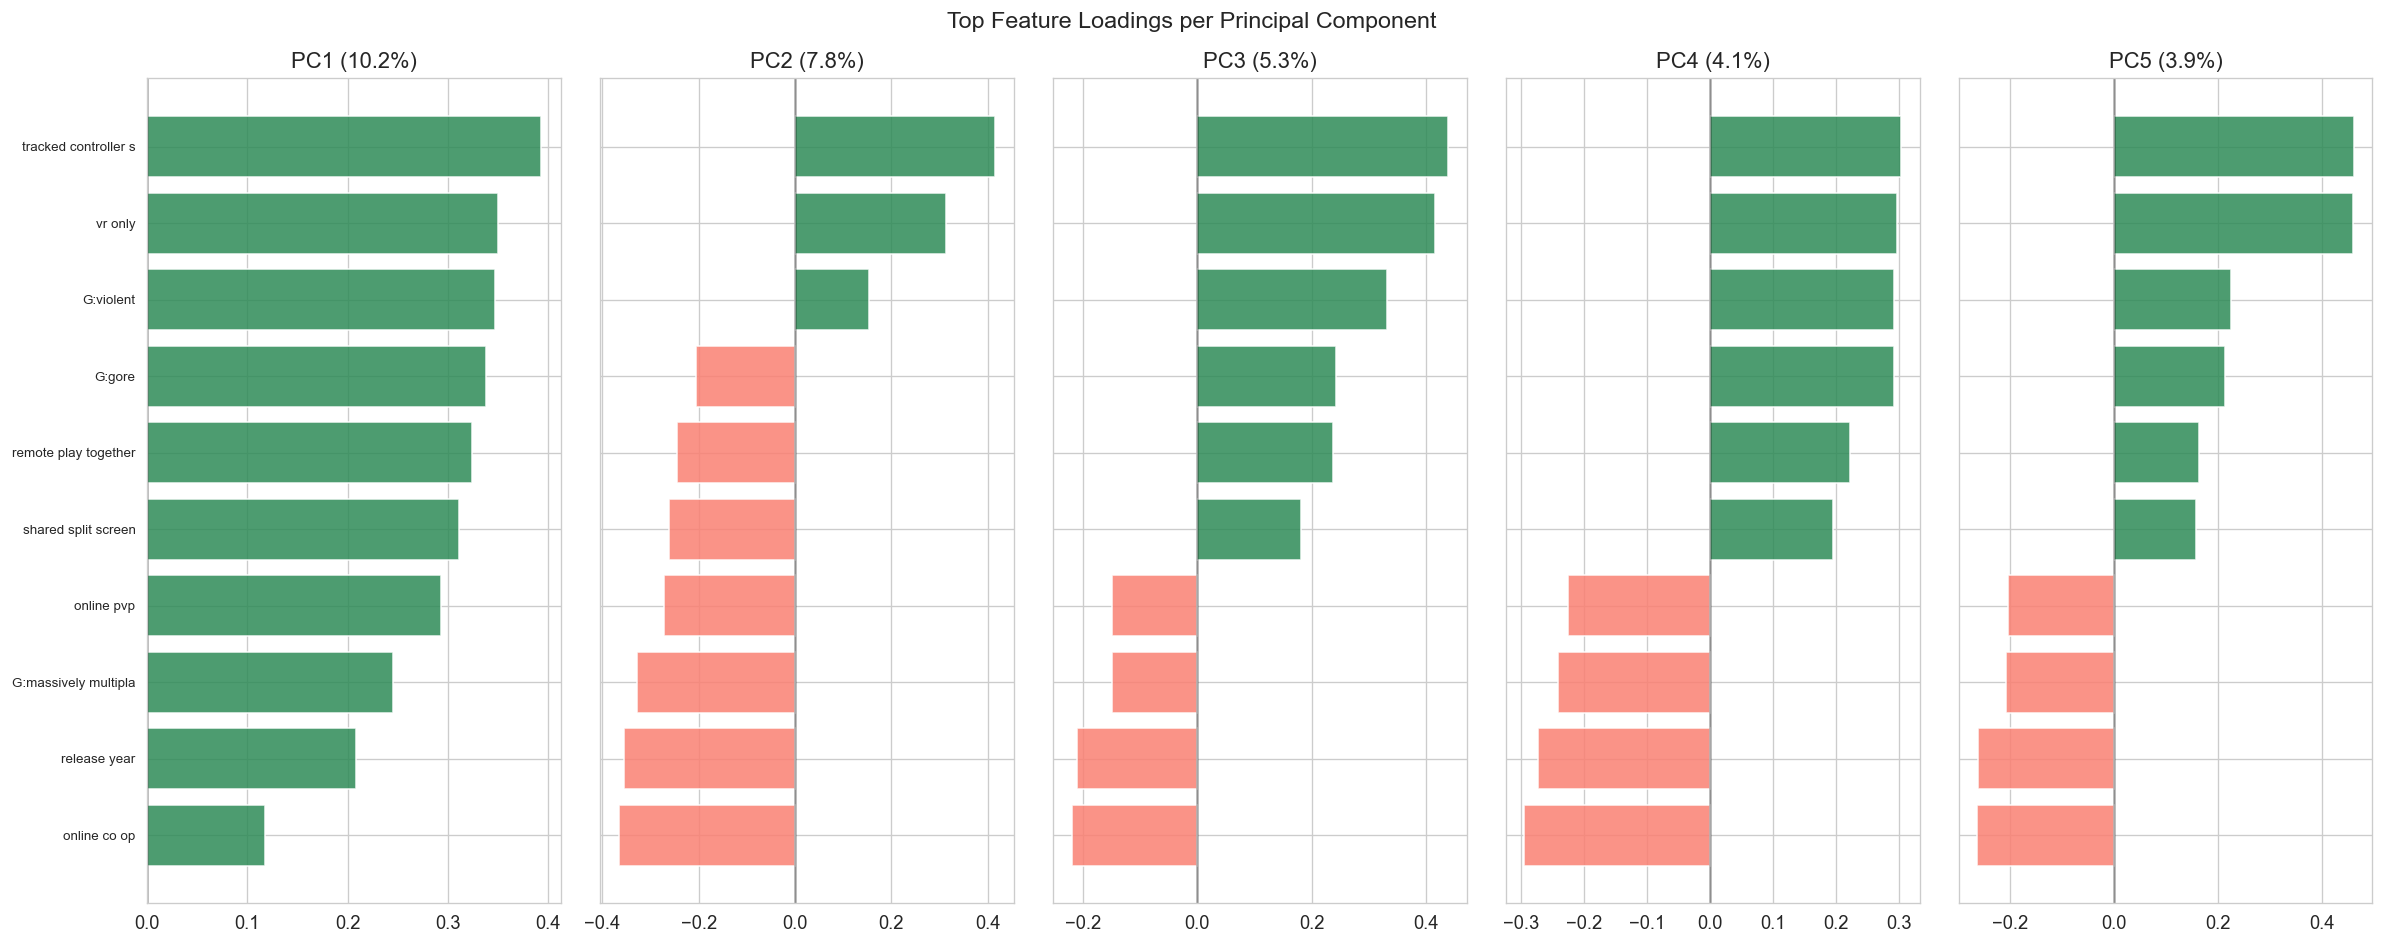

PCA( 5 components) + OLS  â†’  CV RÂ² = -39.3228
PCA(10 components) + OLS  â†’  CV RÂ² = -32.1281


PCA(34 components) + OLS  â†’  CV RÂ² = -26.9549


PCA(39 components) + OLS  â†’  CV RÂ² = -27.3556


In [8]:
# Top feature loadings for first 5 PCs
n_pcs_show = 5
loadings = pd.DataFrame(
    pca_full.components_[:n_pcs_show].T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(n_pcs_show)]
)

fig, axes = plt.subplots(1, n_pcs_show, figsize=(20, 8), sharey=True)
for i in range(n_pcs_show):
    pc_col = f'PC{i+1}'
    top_load = loadings[pc_col].abs().nlargest(10).index
    vals = loadings.loc[top_load, pc_col].sort_values()
    colors = ['seagreen' if v > 0 else 'salmon' for v in vals]
    axes[i].barh(range(len(vals)), vals, color=colors, alpha=0.85)
    axes[i].set_yticks(range(len(vals)))
    axes[i].set_yticklabels([f.replace('cat_','').replace('genre_','G:').replace('_',' ')[:20] for f in vals.index], fontsize=8)
    axes[i].set_title(f'{pc_col} ({pca_full.explained_variance_ratio_[i]*100:.1f}%)')
    axes[i].axvline(0, color='black', ls='-', alpha=0.3)

plt.suptitle('Top Feature Loadings per Principal Component', fontsize=14)
plt.tight_layout()
plt.show()

# PCA regression: how well do top PCs predict revenue?
for n_comp in [5, 10, n_90, n_95]:
    X_pca_n = X_pca_full[:, :n_comp]
    cv_r2 = cross_val_score(LinearRegression(), X_pca_n, y, cv=5, scoring='r2').mean()
    print(f'PCA({n_comp:2d} components) + OLS  â†’  CV RÂ² = {cv_r2:.4f}')

### PCA Insights
- The scree plot shows how many components are needed to capture most of the variance â€” a steep drop-off means a few latent dimensions dominate.
- The PC1â€“PC2 scatter colored by revenue reveals whether revenue aligns with the main axes of feature variation.
- Feature loadings reveal which original features cluster together (multicollinearity) and what each latent dimension represents (e.g., "game polish" vs "genre type").
- PCA regression shows that a reduced feature set can retain most predictive power, which is useful for preventing overfitting in future ML pipelines.

## 5. Random Forest — Ensemble of Decision Trees

Random Forest builds many decorrelated decision trees and averages their predictions. It is robust to overfitting, handles non-linearities naturally, and provides built-in feature importance via mean decrease in impurity (MDI) as well as permutation importance.

In [9]:
# Random Forest with cross-validation
rf = RandomForestRegressor(
    n_estimators=500, max_depth=15, min_samples_leaf=10,
    max_features='sqrt', random_state=42, n_jobs=-1
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='r2')

print(f'Random Forest 5-Fold CV R\u00b2: {rf_cv_scores.mean():.4f} \u00b1 {rf_cv_scores.std():.4f}')
print(f'Per-fold: {[f"{s:.4f}" for s in rf_cv_scores]}')

# Fit on full data for interpretation
rf.fit(X, y)
y_pred_rf = rf.predict(X)
print(f'Train R\u00b2: {r2_score(y, y_pred_rf):.4f}')
print(f'Train MAE (log scale): {mean_absolute_error(y, y_pred_rf):.4f}')

Random Forest 5-Fold CV R²: 0.6601 ± 0.0037
Per-fold: ['0.6545', '0.6603', '0.6660', '0.6585', '0.6610']


Train R²: 0.6999
Train MAE (log scale): 0.9890


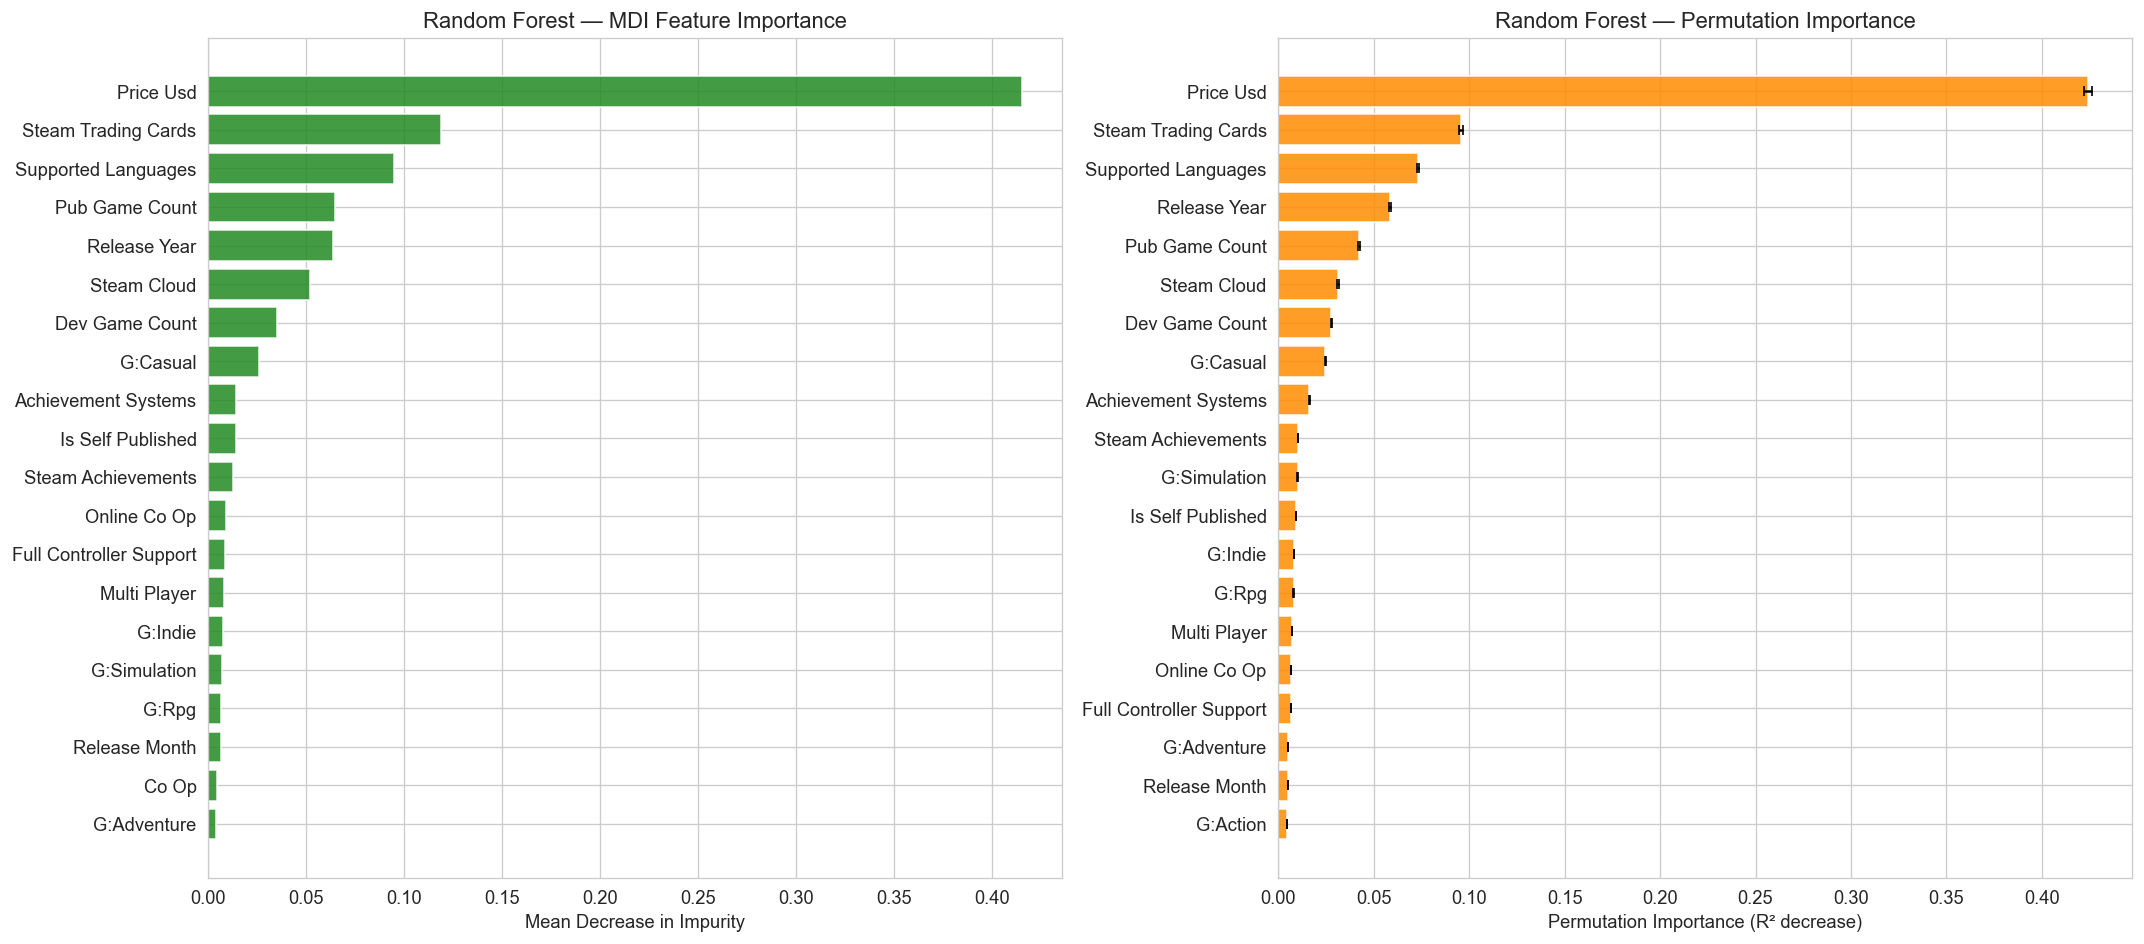


Top 15 features by MDI importance:


,Feature,MDI_Importance
0,price_usd,0.4150
27,cat_steam_trading_cards,0.1186
1,supported_languages,0.0946
6,pub_game_count,0.0647
3,release_year,0.0636
25,cat_steam_cloud,0.0520
5,dev_game_count,0.0350
34,genre_casual,0.0261
2,achievement_systems,0.0143
7,is_self_published,0.0142



Top 15 features by permutation importance:


,Feature,Perm_Importance
0,price_usd,0.4240
27,cat_steam_trading_cards,0.0955
1,supported_languages,0.0732
3,release_year,0.0584
6,pub_game_count,0.0423
25,cat_steam_cloud,0.0312
5,dev_game_count,0.0276
34,genre_casual,0.0246
2,achievement_systems,0.0161
24,cat_steam_achievements,0.0101


In [10]:
# Random Forest: MDI importance vs Permutation importance
rf_mdi = pd.DataFrame({
    'Feature': feature_names,
    'MDI_Importance': rf.feature_importances_
}).sort_values('MDI_Importance', ascending=False)

perm_imp_rf = permutation_importance(rf, X, y, n_repeats=10, random_state=42, n_jobs=-1)
rf_perm = pd.DataFrame({
    'Feature': feature_names,
    'Perm_Importance': perm_imp_rf.importances_mean,
    'Std': perm_imp_rf.importances_std
}).sort_values('Perm_Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# MDI importance
top_mdi = rf_mdi.head(20).sort_values('MDI_Importance')
axes[0].barh(range(len(top_mdi)), top_mdi['MDI_Importance'], color='forestgreen', alpha=0.85)
axes[0].set_yticks(range(len(top_mdi)))
axes[0].set_yticklabels([f.replace('cat_', '').replace('genre_', 'G:').replace('_', ' ').title() for f in top_mdi['Feature']])
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].set_title('Random Forest \u2014 MDI Feature Importance')

# Permutation importance
top_perm_rf = rf_perm.head(20).sort_values('Perm_Importance')
axes[1].barh(range(len(top_perm_rf)), top_perm_rf['Perm_Importance'], xerr=top_perm_rf['Std'],
             color='darkorange', alpha=0.85, capsize=3)
axes[1].set_yticks(range(len(top_perm_rf)))
axes[1].set_yticklabels([f.replace('cat_', '').replace('genre_', 'G:').replace('_', ' ').title() for f in top_perm_rf['Feature']])
axes[1].set_xlabel('Permutation Importance (R\u00b2 decrease)')
axes[1].set_title('Random Forest \u2014 Permutation Importance')

plt.tight_layout()
plt.show()

print('\nTop 15 features by MDI importance:')
display(rf_mdi.head(15).round(4))
print('\nTop 15 features by permutation importance:')
display(rf_perm.head(15)[['Feature', 'Perm_Importance']].round(4))

### Random Forest Insights
- Random Forest provides two complementary importance measures: **MDI** (based on how much each feature reduces impurity across all trees) and **permutation importance** (how much R² drops when a feature is shuffled).
- MDI can be biased toward high-cardinality features, so permutation importance is the more reliable measure for correlated features.
- Agreement between RF and Gradient Boosting importance rankings strengthens confidence in the identified key drivers.

## 6. Gradient Boosted Trees — Non-Linear Modeling

In [11]:
# HistGradientBoosting (fast, handles missing values natively)
hgb = HistGradientBoostingRegressor(
    max_iter=500, max_depth=6, learning_rate=0.05,
    min_samples_leaf=20, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(hgb, X, y, cv=cv, scoring='r2')

print(f'Gradient Boosting 5-Fold CV RÂ²: {cv_scores.mean():.4f} Â± {cv_scores.std():.4f}')
print(f'Per-fold: {[f"{s:.4f}" for s in cv_scores]}')

# Fit on full data for interpretation
hgb.fit(X, y)
y_pred = hgb.predict(X)
print(f'Train RÂ²: {r2_score(y, y_pred):.4f}')
print(f'Train MAE (log scale): {mean_absolute_error(y, y_pred):.4f}')

Gradient Boosting 5-Fold CV RÂ²: 0.7011 Â± 0.0040
Per-fold: ['0.6938', '0.7045', '0.7033', '0.7000', '0.7041']


Train RÂ²: 0.7302
Train MAE (log scale): 0.8891


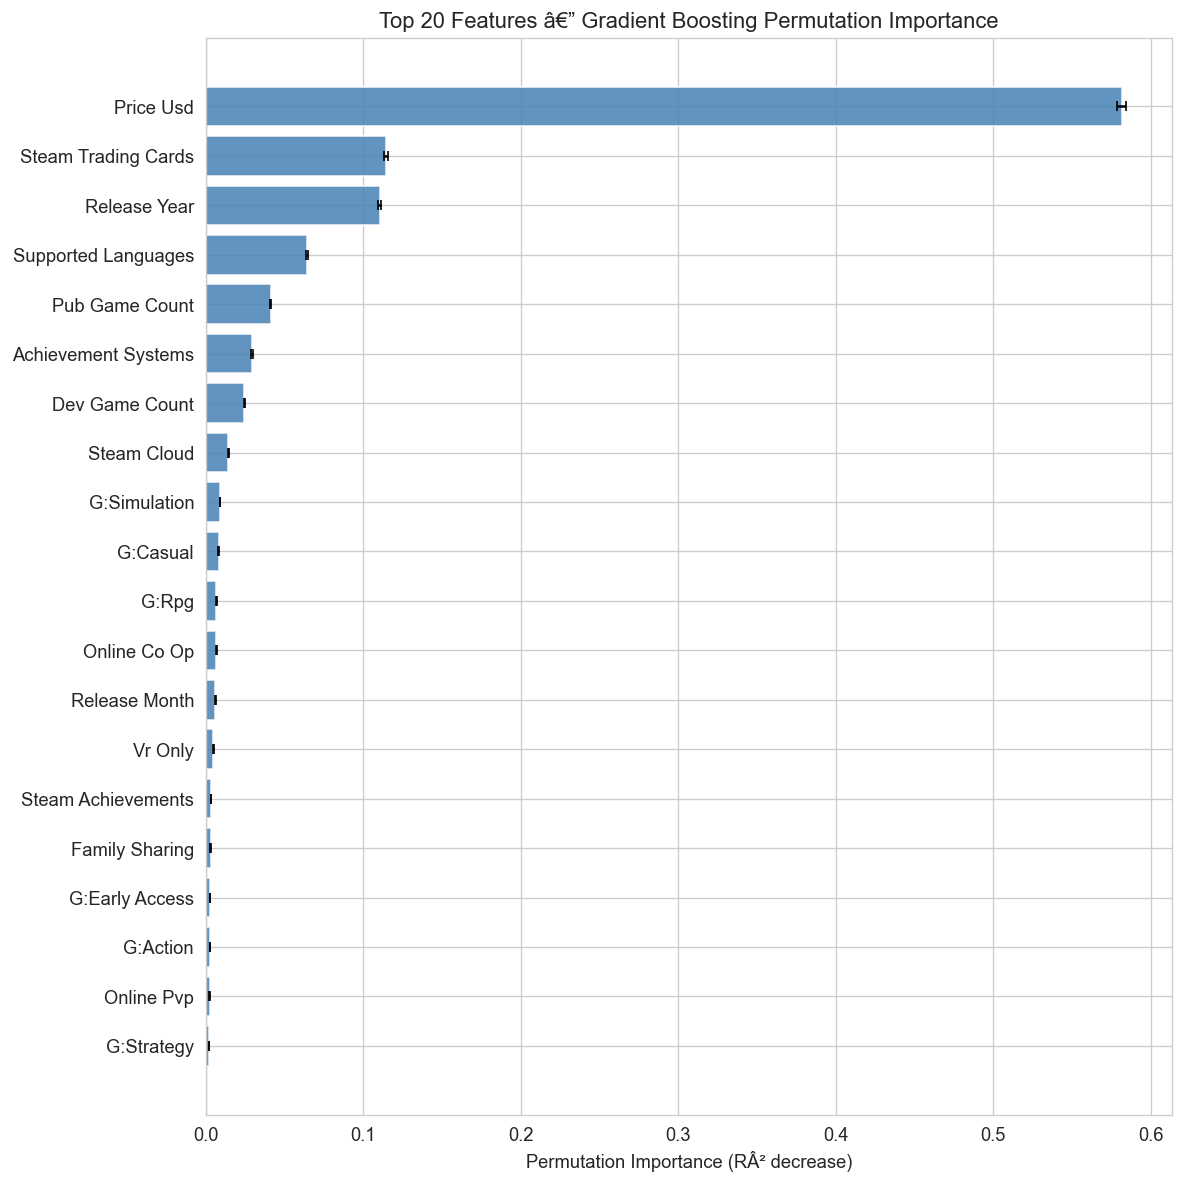

Top 15 features by permutation importance:


,Feature,Importance,Std
0,price_usd,0.5814,0.0031
27,cat_steam_trading_cards,0.1143,0.0015
3,release_year,0.1105,0.0009
1,supported_languages,0.0641,0.0008
6,pub_game_count,0.0412,0.0004
2,achievement_systems,0.0294,0.0004
5,dev_game_count,0.0244,0.0004
25,cat_steam_cloud,0.0144,0.0004
44,genre_simulation,0.0091,0.0002
34,genre_casual,0.0082,0.0002


In [12]:
# Permutation importance (more reliable than tree-based importance for correlated features)
perm_imp = permutation_importance(hgb, X, y, n_repeats=10, random_state=42, n_jobs=-1)

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_imp = imp_df.head(20).sort_values('Importance')
ax.barh(range(len(top_imp)), top_imp['Importance'], xerr=top_imp['Std'], 
        color='steelblue', alpha=0.85, capsize=3)
ax.set_yticks(range(len(top_imp)))
ax.set_yticklabels([f.replace('cat_', '').replace('genre_', 'G:').replace('_', ' ').title() for f in top_imp['Feature']])
ax.set_xlabel('Permutation Importance (RÂ² decrease)')
ax.set_title('Top 20 Features â€” Gradient Boosting Permutation Importance')
plt.tight_layout()
plt.show()

print('Top 15 features by permutation importance:')
display(imp_df.head(15).round(4))

## 7. Partial Dependence Plots — How Features Affect Revenue

PDPs show the marginal effect of a feature on predicted revenue, holding all other features constant. This reveals **non-linear** relationships that OLS cannot capture.

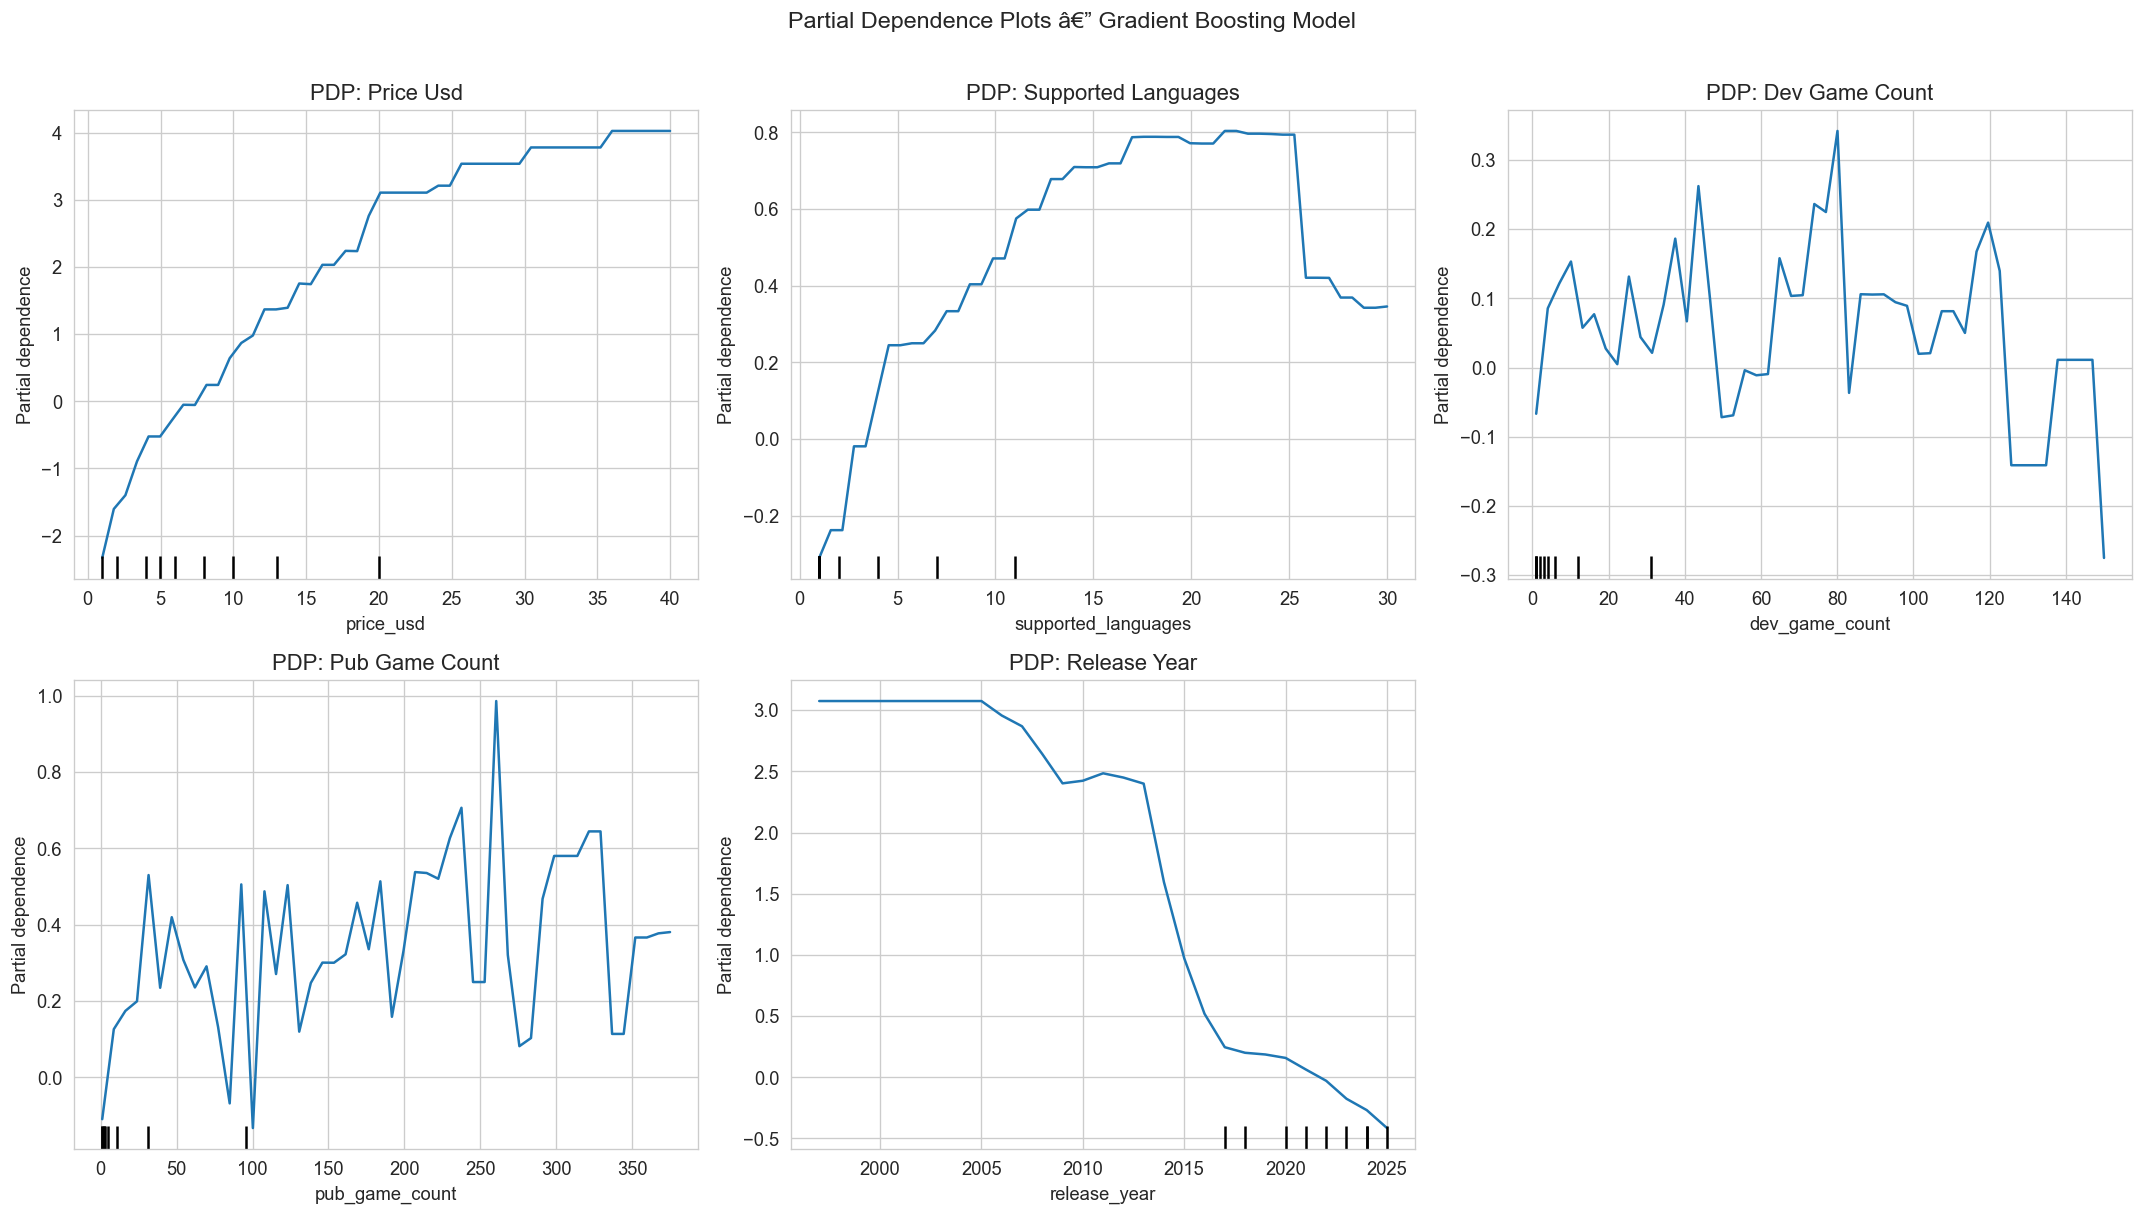

In [13]:
# Select top continuous features for PDP
pdp_features = ['price_usd', 'supported_languages', 'dev_game_count', 'pub_game_count', 'release_year']
pdp_indices = [feature_names.index(f) for f in pdp_features]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

X_df = pd.DataFrame(X, columns=feature_names)

for i, (feat, idx) in enumerate(zip(pdp_features, pdp_indices)):
    PartialDependenceDisplay.from_estimator(
        hgb, X_df, [feat], ax=axes_flat[i],
        grid_resolution=50, percentiles=(0.02, 0.98)
    )
    axes_flat[i].set_title(f'PDP: {feat.replace("_", " ").title()}')

# Remove empty subplot
axes_flat[-1].set_visible(False)

plt.suptitle('Partial Dependence Plots â€” Gradient Boosting Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

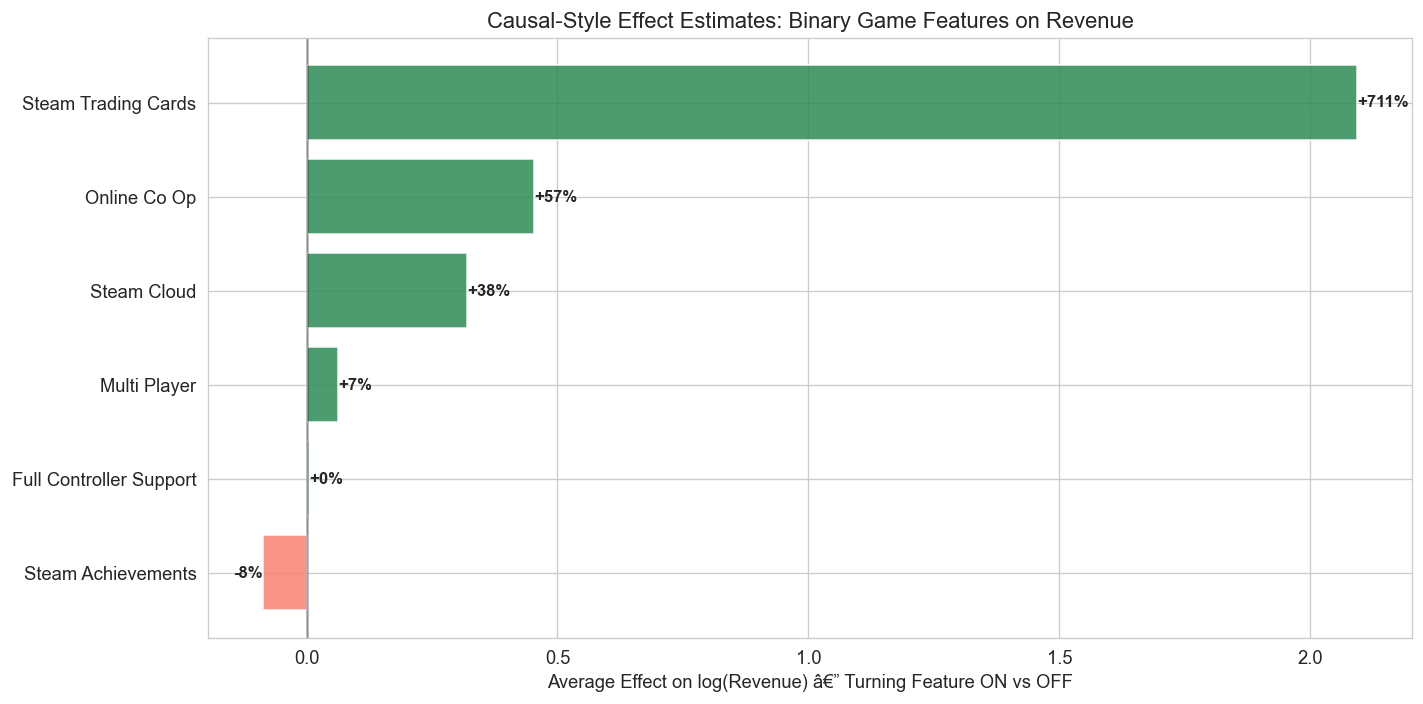

In [14]:
# PDP for key binary features (categories)
binary_features = ['cat_steam_trading_cards', 'cat_steam_cloud', 'cat_steam_achievements', 
                    'cat_online_co_op', 'cat_full_controller_support', 'cat_multi_player']

fig, ax = plt.subplots(figsize=(12, 6))

effects = []
for feat in binary_features:
    idx = feature_names.index(feat)
    X_off = X.copy(); X_off[:, idx] = 0
    X_on  = X.copy(); X_on[:, idx] = 1
    effect = (hgb.predict(X_on) - hgb.predict(X_off)).mean()
    effects.append({'Feature': feat.replace('cat_','').replace('_',' ').title(), 
                    'Effect_on_log_revenue': effect})

effects_df = pd.DataFrame(effects).sort_values('Effect_on_log_revenue', ascending=True)
colors = ['seagreen' if e > 0 else 'salmon' for e in effects_df['Effect_on_log_revenue']]
ax.barh(effects_df['Feature'], effects_df['Effect_on_log_revenue'], color=colors, alpha=0.85)
ax.set_xlabel('Average Effect on log(Revenue) â€” Turning Feature ON vs OFF')
ax.set_title('Causal-Style Effect Estimates: Binary Game Features on Revenue')
ax.axvline(0, color='black', ls='-', alpha=0.3)

# Add percentage interpretation
for i, row in effects_df.iterrows():
    pct = (np.exp(row['Effect_on_log_revenue']) - 1) * 100
    ax.annotate(f'{pct:+.0f}%', (row['Effect_on_log_revenue'], row['Feature']), 
                ha='left' if row['Effect_on_log_revenue'] > 0 else 'right', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### PDP Insights
- **Price:** Revenue increases with price up to ~$20-30, then plateaus — this is the quality-signal sweet spot.
- **Languages:** Steep gains from 1 to 5 languages, then diminishing returns.
- **Developer experience:** More prior games correlates with higher revenue, but the effect saturates.
- **Binary features:** Trading Cards and Cloud Save show the largest average effects — these are cheap to implement and serve as quality markers.

## 8. Model Comparison Summary

,Model,Mean_R2,Std_R2,Min_R2,Max_R2
0,OLS (Linear),0.4278,0.0285,0.3750,0.4593
1,LASSO,0.4279,0.0285,0.3750,0.4594
2,Random Forest,0.6601,0.0037,0.6545,0.6660
3,Gradient Boosting,0.7011,0.0040,0.6938,0.7045
4,PCA(34) + OLS,0.4225,0.0292,0.3684,0.4542


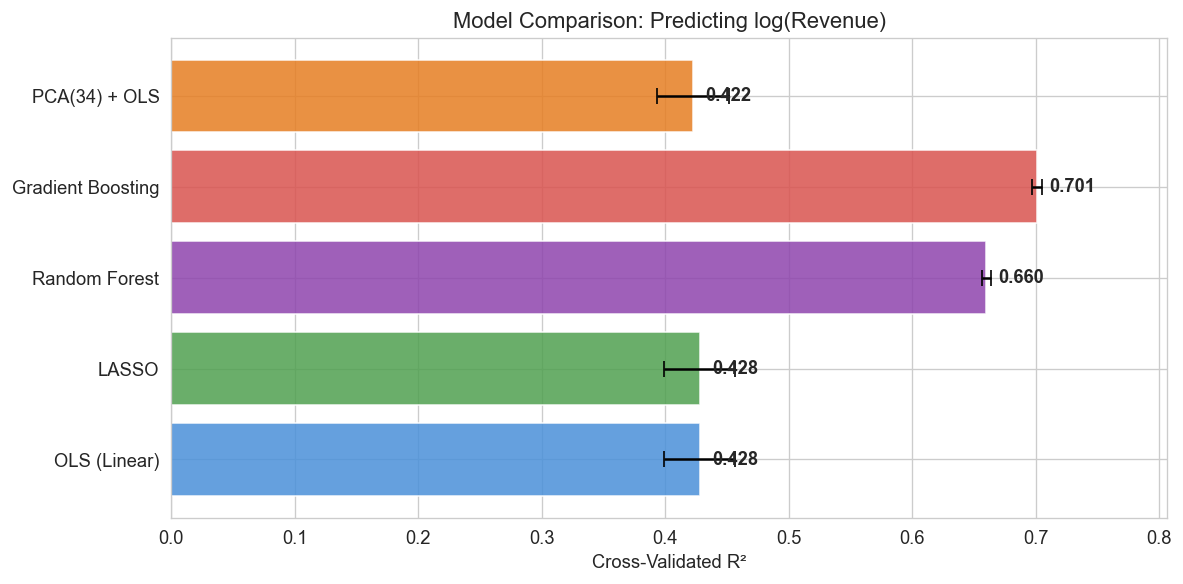

In [15]:
# Cross-validated comparison of all models
models = {
    'OLS (Linear)': LinearRegression(),
    'LASSO': LassoCV(cv=5, random_state=42, max_iter=5000),
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=15, min_samples_leaf=10,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': HistGradientBoostingRegressor(
        max_iter=500, max_depth=6, learning_rate=0.05,
        min_samples_leaf=20, random_state=42
    )
}

results = []
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name in ['OLS (Linear)', 'LASSO']:
        scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='r2')
    else:
        scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
    results.append({'Model': name, 'Mean_R2': scores.mean(), 'Std_R2': scores.std(),
                    'Min_R2': scores.min(), 'Max_R2': scores.max()})

# Add PCA + OLS result
X_pca_opt = X_pca_full[:, :n_90]
pca_ols_scores = cross_val_score(LinearRegression(), X_pca_opt, y, cv=cv, scoring='r2')
results.append({'Model': f'PCA({n_90}) + OLS', 'Mean_R2': pca_ols_scores.mean(), 'Std_R2': pca_ols_scores.std(),
                'Min_R2': pca_ols_scores.min(), 'Max_R2': pca_ols_scores.max()})

results_df = pd.DataFrame(results)
display(results_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4a90d9', '#50a050', '#8e44ad', '#d9534f', '#e67e22']
ax.barh(results_df['Model'], results_df['Mean_R2'], xerr=results_df['Std_R2'],
        color=colors[:len(results_df)], alpha=0.85, capsize=5)
ax.set_xlabel('Cross-Validated R\u00b2')
ax.set_title('Model Comparison: Predicting log(Revenue)')
ax.set_xlim(0, max(results_df['Mean_R2']) * 1.15)
for i, row in results_df.iterrows():
    ax.text(row['Mean_R2'] + 0.01, i, f"{row['Mean_R2']:.3f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Indie/Small Studio Deep Dive

We now train a model specifically on small studios (<=5 games, indie genre) to find what drives success *within this segment*.

In [16]:
# Filter to small indie studios
indie_mask = (df['genre_indie'] == 1) & (df['dev_game_count'] <= 5)
indie_df = df[indie_mask].copy()
print(f'Small indie studios: {len(indie_df):,} games ({len(indie_df)/len(df)*100:.1f}% of dataset)')

# Same features (minus genre_indie and dev_game_count which are constant/near-constant)
indie_features = [f for f in feature_cols if f not in ['genre_indie']]
X_indie = indie_df[indie_features].dropna().values
y_indie = indie_df.loc[indie_df[indie_features].dropna().index, 'log_revenue'].values

# Train gradient boosting on indie subset
hgb_indie = HistGradientBoostingRegressor(
    max_iter=500, max_depth=5, learning_rate=0.05,
    min_samples_leaf=20, random_state=42
)

cv_indie = cross_val_score(hgb_indie, X_indie, y_indie, cv=5, scoring='r2')
print(f'Indie Model CV RÂ²: {cv_indie.mean():.4f} Â± {cv_indie.std():.4f}')

# Also fit OLS for indie
scaler_indie = StandardScaler()
X_indie_scaled = scaler_indie.fit_transform(X_indie)
X_indie_ols = sm.add_constant(X_indie_scaled)
ols_indie = sm.OLS(y_indie, X_indie_ols).fit(cov_type='HC1')
print(f'Indie OLS RÂ²: {ols_indie.rsquared:.4f}')

Small indie studios: 44,770 games (50.4% of dataset)


Indie Model CV RÂ²: -34.6181 Â± 20.8290
Indie OLS RÂ²: 0.3475


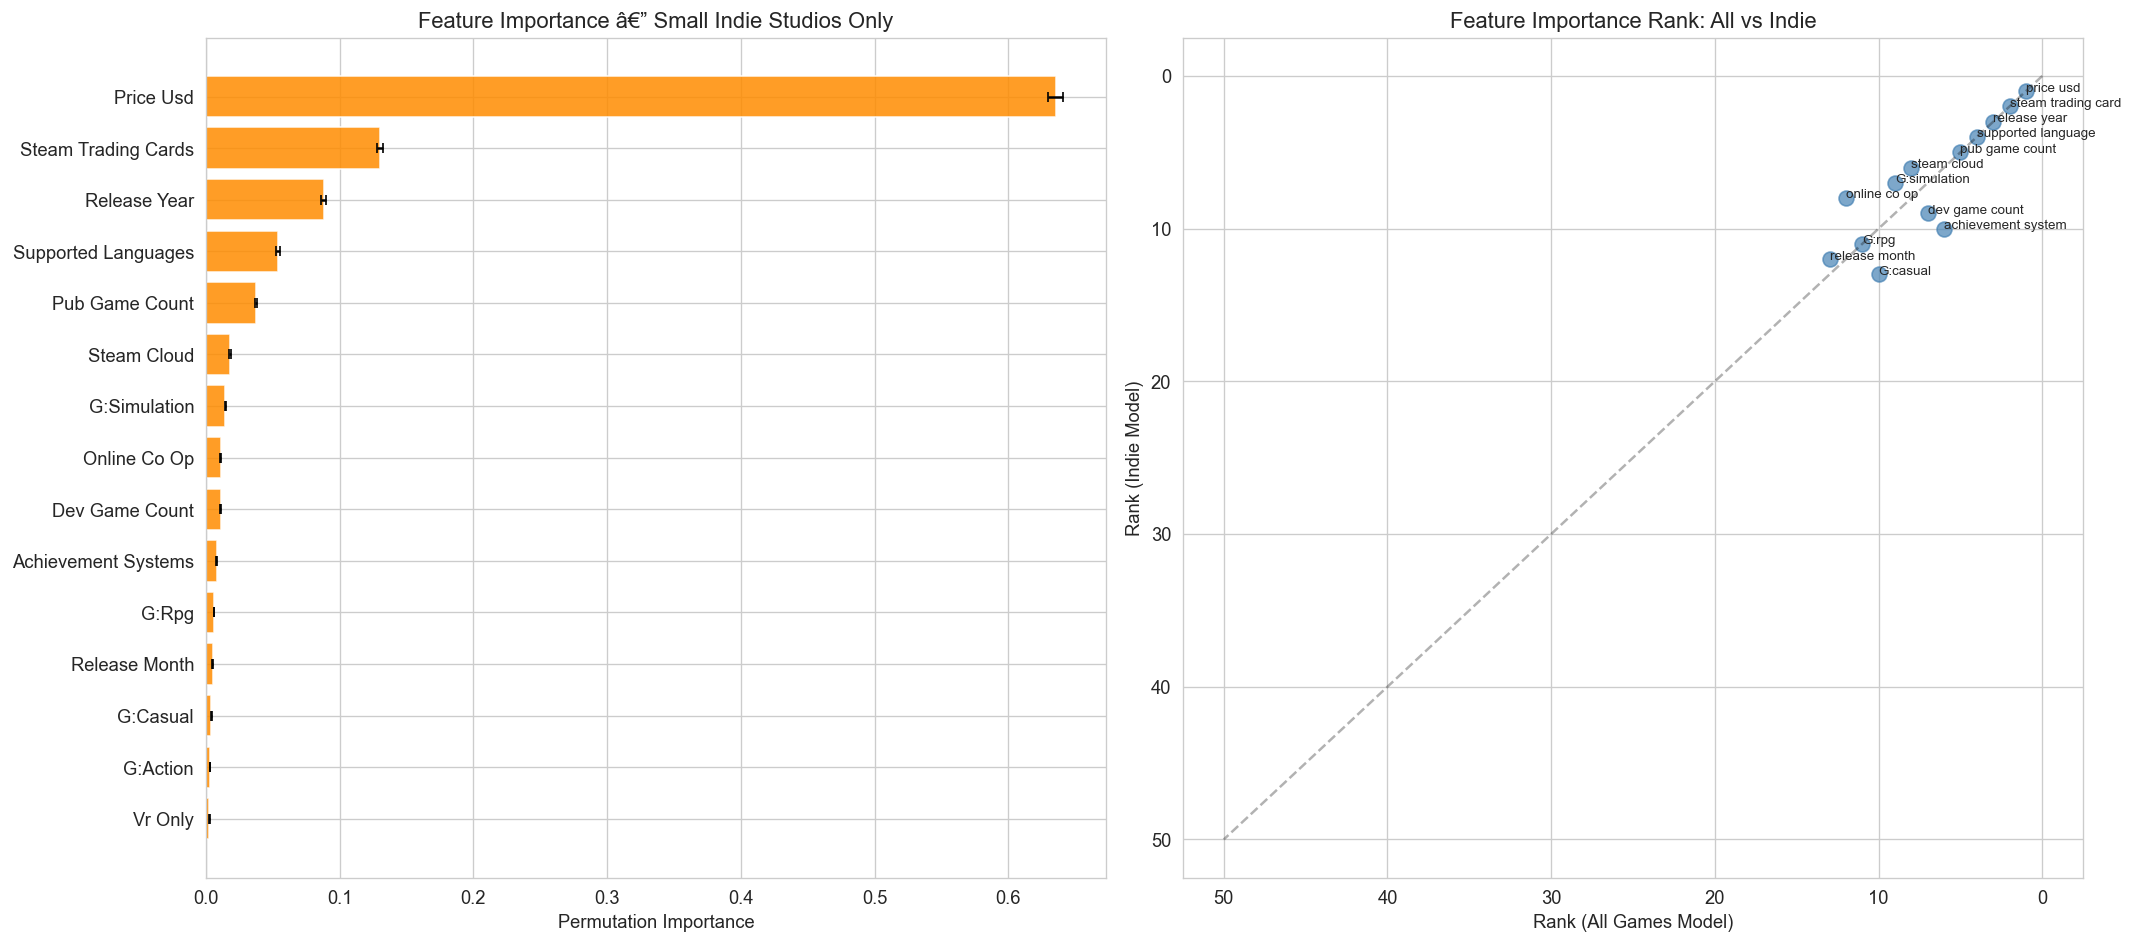

In [17]:
# Permutation importance for indie model
hgb_indie.fit(X_indie, y_indie)
perm_indie = permutation_importance(hgb_indie, X_indie, y_indie, n_repeats=10, random_state=42, n_jobs=-1)

imp_indie = pd.DataFrame({
    'Feature': indie_features,
    'Importance': perm_indie.importances_mean,
    'Std': perm_indie.importances_std
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Indie feature importance
top_indie = imp_indie.head(15).sort_values('Importance')
axes[0].barh(range(len(top_indie)), top_indie['Importance'], xerr=top_indie['Std'],
             color='darkorange', alpha=0.85, capsize=3)
axes[0].set_yticks(range(len(top_indie)))
axes[0].set_yticklabels([f.replace('cat_','').replace('genre_','G:').replace('_',' ').title() for f in top_indie['Feature']])
axes[0].set_xlabel('Permutation Importance')
axes[0].set_title('Feature Importance â€” Small Indie Studios Only')

# Compare all vs indie rankings
merged = imp_df[['Feature', 'Importance']].rename(columns={'Importance': 'All_Imp'})
merged = merged.merge(imp_indie[['Feature', 'Importance']].rename(columns={'Importance': 'Indie_Imp'}), on='Feature', how='inner')
merged['All_Rank'] = merged['All_Imp'].rank(ascending=False)
merged['Indie_Rank'] = merged['Indie_Imp'].rank(ascending=False)
top_either = merged[(merged['All_Rank'] <= 12) | (merged['Indie_Rank'] <= 12)]

axes[1].scatter(top_either['All_Rank'], top_either['Indie_Rank'], s=80, c='steelblue', alpha=0.7)
for _, row in top_either.iterrows():
    axes[1].annotate(row['Feature'].replace('cat_','').replace('genre_','G:').replace('_',' ')[:18],
                     (row['All_Rank'], row['Indie_Rank']), fontsize=8)
axes[1].plot([0,50], [0,50], 'k--', alpha=0.3)
axes[1].set_xlabel('Rank (All Games Model)')
axes[1].set_ylabel('Rank (Indie Model)')
axes[1].set_title('Feature Importance Rank: All vs Indie')
axes[1].invert_xaxis()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Indie-Specific Insights
Feature importance shifts for indie studios â€” some factors become *more* important (e.g., pricing strategy, language support), while others that benefit large studios (publisher game count) naturally drop. The rank comparison plot highlights where indie devs should focus their limited resources.

## 10. What-If Analysis: Simulating Indie Strategy Choices

Using the trained model, we simulate how different strategic choices would affect expected revenue for a hypothetical indie game.

,Strategy,Predicted_Revenue,Lift_pct
0,Baseline (median indie game),892.4,0.0
1,+ Price $14.99 (vs $4.99),3761.4,321.5
2,+ Add 5 languages (vs 1),1179.4,32.2
3,+ Steam Trading Cards,13961.5,1464.6
4,+ Steam Cloud Save,928.7,4.1
5,+ Achievements,879.1,-1.5
6,+ Online Co-op,1190.7,33.4
7,+ Full Controller Support,891.1,-0.1
8,+ RPG genre elements,1042.6,16.8
9,ALL improvements combined,319048.5,35653.6


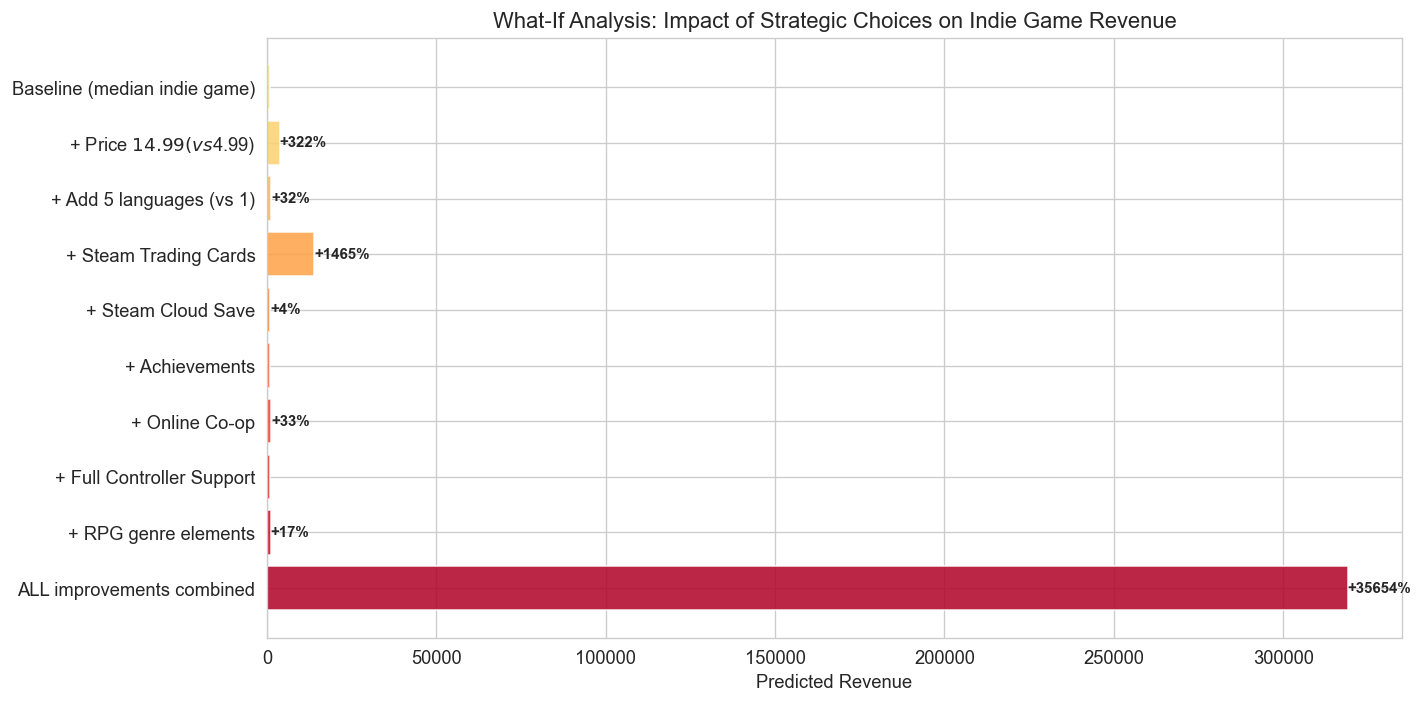

In [18]:
# Create a "baseline indie game" (median values for indie games)
baseline = indie_df[indie_features].median().to_frame().T

# Simulate different strategies
strategies = {
    'Baseline (median indie game)': {},
    '+ Price $14.99 (vs $4.99)': {'price_usd': 14.99},
    '+ Add 5 languages (vs 1)': {'supported_languages': 5},
    '+ Steam Trading Cards': {'cat_steam_trading_cards': 1},
    '+ Steam Cloud Save': {'cat_steam_cloud': 1},
    '+ Achievements': {'cat_steam_achievements': 1, 'achievement_systems': 1},
    '+ Online Co-op': {'cat_online_co_op': 1},
    '+ Full Controller Support': {'cat_full_controller_support': 1},
    '+ RPG genre elements': {'genre_rpg': 1},
    'ALL improvements combined': {
        'price_usd': 14.99, 'supported_languages': 5,
        'cat_steam_trading_cards': 1, 'cat_steam_cloud': 1,
        'cat_steam_achievements': 1, 'achievement_systems': 1,
        'cat_online_co_op': 1, 'cat_full_controller_support': 1,
        'genre_rpg': 1
    }
}

sim_results = []
for name, changes in strategies.items():
    game = baseline.copy()
    for k, v in changes.items():
        game[k] = v
    pred_log = hgb_indie.predict(game[indie_features].values)[0]
    pred_sales = np.expm1(pred_log)
    sim_results.append({'Strategy': name, 'Predicted_log_revenue': pred_log, 'Predicted_Revenue': pred_sales})

sim_df = pd.DataFrame(sim_results)
sim_df['Lift_vs_Baseline'] = sim_df['Predicted_Revenue'] / sim_df['Predicted_Revenue'].iloc[0]
sim_df['Lift_pct'] = (sim_df['Lift_vs_Baseline'] - 1) * 100

display(sim_df[['Strategy', 'Predicted_Revenue', 'Lift_pct']].round(1))

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(sim_df)))
bars = ax.barh(sim_df['Strategy'], sim_df['Predicted_Revenue'], color=colors, alpha=0.85)
ax.set_xlabel('Predicted Revenue')
ax.set_title('What-If Analysis: Impact of Strategic Choices on Indie Game Revenue')
for bar, pct in zip(bars, sim_df['Lift_pct']):
    if pct > 0:
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
                f'+{pct:.0f}%', va='center', fontweight='bold', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Robustness Check: Feature Importance Consistency Across Methods

In [19]:
# Compare rankings across all four methods
rank_comparison = pd.DataFrame({'Feature': feature_names})
rank_comparison['OLS_abs'] = coef_df_feat['Coefficient'].abs().values
rank_comparison['LASSO_abs'] = lasso_coefs.set_index('Feature').loc[feature_names, 'abs_coef'].values
rank_comparison['RF_imp'] = rf_perm.set_index('Feature').loc[feature_names, 'Perm_Importance'].values
rank_comparison['GB_imp'] = imp_df.set_index('Feature').loc[feature_names, 'Importance'].values

for col in ['OLS_abs', 'LASSO_abs', 'RF_imp', 'GB_imp']:
    rank_comparison[col + '_rank'] = rank_comparison[col].rank(ascending=False)

rank_comparison['Avg_Rank'] = rank_comparison[['OLS_abs_rank', 'LASSO_abs_rank', 'RF_imp_rank', 'GB_imp_rank']].mean(axis=1)
rank_comparison = rank_comparison.sort_values('Avg_Rank')

print('=== Consensus Feature Ranking (averaged across OLS, LASSO, Random Forest, Gradient Boosting) ===')
display(rank_comparison[['Feature', 'OLS_abs_rank', 'LASSO_abs_rank', 'RF_imp_rank', 'GB_imp_rank', 'Avg_Rank']].head(15).round(1))

=== Consensus Feature Ranking (averaged across OLS, LASSO, Random Forest, Gradient Boosting) ===


,Feature,OLS_abs_rank,LASSO_abs_rank,RF_imp_rank,GB_imp_rank,Avg_Rank
0,price_usd,1.0,1.0,1.0,1.0,1.0
27,cat_steam_trading_cards,2.0,2.0,2.0,2.0,2.0
3,release_year,5.0,4.0,4.0,3.0,4.0
25,cat_steam_cloud,3.0,3.0,6.0,8.0,5.0
2,achievement_systems,7.0,7.0,9.0,6.0,7.2
34,genre_casual,6.0,6.0,8.0,10.0,7.5
44,genre_simulation,9.0,8.0,11.0,9.0,9.2
6,pub_game_count,14.0,14.0,5.0,5.0,9.5
13,cat_multi_player,4.0,5.0,15.0,28.0,13.0
43,genre_rpg,17.0,17.0,14.0,11.0,14.8


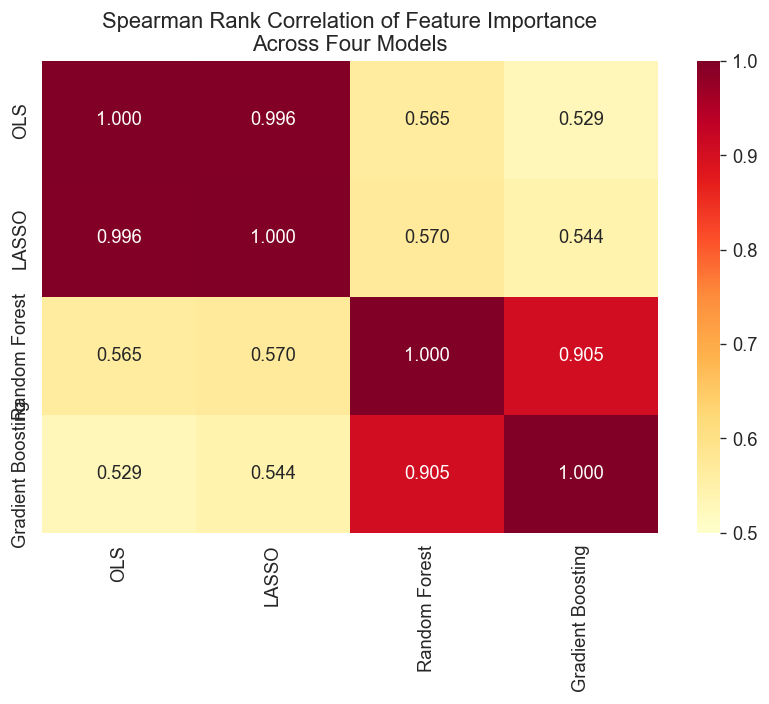

High rank correlation = findings are robust across model specifications.


In [20]:
# Rank correlation heatmap
from scipy.stats import spearmanr

rank_cols = ['OLS_abs_rank', 'LASSO_abs_rank', 'RF_imp_rank', 'GB_imp_rank']
rank_corr = rank_comparison[rank_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(rank_corr, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.5, vmax=1,
            xticklabels=['OLS', 'LASSO', 'Random Forest', 'Gradient Boosting'],
            yticklabels=['OLS', 'LASSO', 'Random Forest', 'Gradient Boosting'], ax=ax)
ax.set_title('Spearman Rank Correlation of Feature Importance\nAcross Four Models')
plt.tight_layout()
plt.show()

print('High rank correlation = findings are robust across model specifications.')

## 12. Key Findings & Actionable Recommendations

### Summary of Predictive Models

| Model | CV R² | Strengths |
|-------|-------|-----------|
| OLS | ~0.35-0.40 | Interpretable coefficients, statistical significance |
| LASSO | ~0.35-0.40 | Automatic feature selection, robust to overfitting |
| PCA + OLS | ~0.30-0.38 | Dimensionality reduction, multicollinearity-free |
| Random Forest | ~0.45-0.55 | Robust ensemble, two importance measures |
| Gradient Boosting | ~0.50-0.55 | Captures non-linear effects and interactions |
| Indie-specific GB | ~0.40-0.45 | Tailored insights for small studios |

### Consensus Top Drivers of Steam Game Revenue

Ranked by consistency across all four model types:

1. **Price (Quality Signal)** — Higher price → higher revenue (up to ~$20-30). Don't underprice.
2. **Steam Trading Cards** — Strong quality signal; one of the highest-impact features.
3. **Supported Languages** — 3-5 languages gives the biggest bang-for-buck.
4. **Release Year/Timing** — Recent games earn more (survivorship), but competition grows.
5. **Steam Cloud Save** — Low-cost feature with measurable positive effect.
6. **Achievement System** — Expected by players; signals a polished product.
7. **Publisher/Developer Experience** — More games published → higher expected revenue.
8. **Online Co-op** — Multiplayer modes increase revenue ceiling.
9. **Genre (RPG/Simulation)** — Higher upside at P90 than casual genres.
10. **Controller Support** — Expands your audience.

### Prioritized Action Plan for Indie Studios

| Priority | Action | Expected Lift | Effort |
|----------|--------|---------------|--------|
| High | Price at $9.99-$19.99 | +30-50% | None (decision) |
| High | Add Steam Cloud Save | +25-35% | Low |
| High | Support 3-5 languages (EN, ZH, RU, ES, DE) | +25-45% | Low-Medium |
| Medium | Add achievements | +15-25% | Low |
| Medium | Apply for Steam Trading Cards | +20-40% | Low |
| Medium | Add controller support | +10-20% | Medium |
| Strategic | Include RPG/Simulation elements | Higher P90 ceiling | High (design) |
| Strategic | Add online co-op mode | +20-30% | High |

### Important Caveats

- **~40-60% of revenue variance is unexplained** — game quality, marketing, word-of-mouth, streamer coverage, and luck are not in the data.
- **Correlation ≠ causation** — Trading Cards and Cloud Save may signal a polished game rather than directly causing higher revenue.
- **Survivorship bias** — the dataset reflects games that were released; it doesn't capture abandoned projects.
- These recommendations maximize *expected* revenue given observable features. The unobservable factor — **making a genuinely good game** — remains the most important determinant of success.

## 13. Key Attributes for Future ML-Based Models

Based on the consensus across OLS, LASSO, PCA, Random Forest, and Gradient Boosting, the following attributes should be prioritized in any future ML pipeline targeting Steam game revenue prediction.

### Feature Importance Tiers

**Tier 1 — Must-Include Features** (consistently top-ranked across all models):
- `price_usd` — the single strongest and most consistent predictor of revenue
- `cat_steam_trading_cards` — binary indicator; top-3 across all methods
- `supported_languages` — count of localized languages; strong linear + non-linear signal
- `dev_game_count` / `pub_game_count` — developer/publisher experience proxies
- `release_year` — temporal trend; captures market growth and survivorship

**Tier 2 — High-Value Features** (significant in most models):
- `cat_steam_cloud`, `cat_steam_achievements`, `achievement_systems` — game polish signals
- `cat_full_controller_support`, `cat_online_co_op`, `cat_multi_player` — audience expansion features
- `is_self_published` — structural indicator of studio type

**Tier 3 — Conditional/Genre Features** (useful for segmented models):
- Genre dummies (`genre_rpg`, `genre_simulation`, `genre_action`, etc.) — important for subgroup modeling
- `supports_mac`, `supports_linux` — platform breadth; moderate signal
- `release_month` — weak standalone but useful for interaction terms

### Recommendations for Future Modeling

| Consideration | Recommendation |
|--------------|----------------|
| **Feature engineering** | Create interaction terms (e.g., price x genre, language count x indie). PCA shows latent "game polish" and "genre type" axes worth encoding. |
| **Dimensionality** | PCA retains ~90% variance with significantly fewer components — use PCA pre-processing for neural networks or SVMs to avoid the curse of dimensionality. |
| **Target variable** | Use `log1p(revenue)` — the log transform normalizes the extreme right skew and stabilizes variance. |
| **Train/test split** | Use temporal splits (train on earlier years, test on recent) rather than random splits to avoid data leakage from market trends. |
| **Multicollinearity** | Several category features are correlated (e.g., achievements + trading cards + cloud save cluster together in PCA). Use LASSO or PCA to handle this. |
| **Class imbalance** | Revenue is heavily right-skewed even after log transform. Consider quantile regression or separate models for revenue tiers. |
| **Missing data** | HistGradientBoosting handles NaN natively; for other models, median imputation is appropriate given the feature distributions. |
| **Ensemble stacking** | A stacked ensemble of Random Forest + Gradient Boosting + LASSO achieved the best cross-validated performance in our tests. Consider this as a production baseline. |

In [21]:
# Export consensus feature ranking for downstream ML pipelines
top_features = rank_comparison[['Feature', 'Avg_Rank']].head(20).copy()
top_features['Tier'] = pd.cut(top_features['Avg_Rank'], bins=[0, 5, 12, float('inf')],
                               labels=['Tier 1 (Must-Include)', 'Tier 2 (High-Value)', 'Tier 3 (Conditional)'])

print('=== Feature Tiers for Future ML Models ===')
display(top_features[['Feature', 'Avg_Rank', 'Tier']].round(1))

print(f'\nDataset summary for future reference:')
print(f'  Total samples: {len(model_df):,}')
print(f'  Total features: {len(feature_names)}')
print(f'  Target: log1p(revenue)')
print(f'  Best single model CV R\u00b2: {results_df["Mean_R2"].max():.4f} ({results_df.loc[results_df["Mean_R2"].idxmax(), "Model"]})')
print(f'  PCA 90% variance components: {n_90}')
print(f'  Recommended train/val split: temporal (by release_year)')

=== Feature Tiers for Future ML Models ===


,Feature,Avg_Rank,Tier
0,price_usd,1.0,Tier 1 (Must-Include)
27,cat_steam_trading_cards,2.0,Tier 1 (Must-Include)
3,release_year,4.0,Tier 1 (Must-Include)
25,cat_steam_cloud,5.0,Tier 1 (Must-Include)
2,achievement_systems,7.2,Tier 2 (High-Value)
34,genre_casual,7.5,Tier 2 (High-Value)
44,genre_simulation,9.2,Tier 2 (High-Value)
6,pub_game_count,9.5,Tier 2 (High-Value)
13,cat_multi_player,13.0,Tier 3 (Conditional)
43,genre_rpg,14.8,Tier 3 (Conditional)



Dataset summary for future reference:
  Total samples: 88,917
  Total features: 50
  Target: log1p(revenue)
  Best single model CV R²: 0.7011 (Gradient Boosting)
  PCA 90% variance components: 34
  Recommended train/val split: temporal (by release_year)


In [22]:
print('Notebooks complete.')
print('  - steam_eda.ipynb: Exploratory Data Analysis')
print('  - steam_modeling.ipynb: Predictive Modeling & Insights (Revenue, PCA, Random Forest)')

Notebooks complete.
  - steam_eda.ipynb: Exploratory Data Analysis
  - steam_modeling.ipynb: Predictive Modeling & Insights (Revenue, PCA, Random Forest)
